PART 1: GMM SYNTHETIC DATASET GENERATION

Dataset successfully generated!
Number of records : 600
Number of clusters: 3

--------------------------------------------------------------------------------
SAMPLE OF 10 DATA POINTS
--------------------------------------------------------------------------------


,Feature_X,Feature_Y,Cluster
0,1.627,2.016,2
1,3.799,-0.824,3
2,3.057,-2.814,3
3,1.473,2.257,2
4,-2.214,-1.999,1
5,-2.437,-2.282,1
6,-2.084,-2.194,1
7,2.659,0.254,3
8,0.056,1.463,2
9,3.791,0.419,3


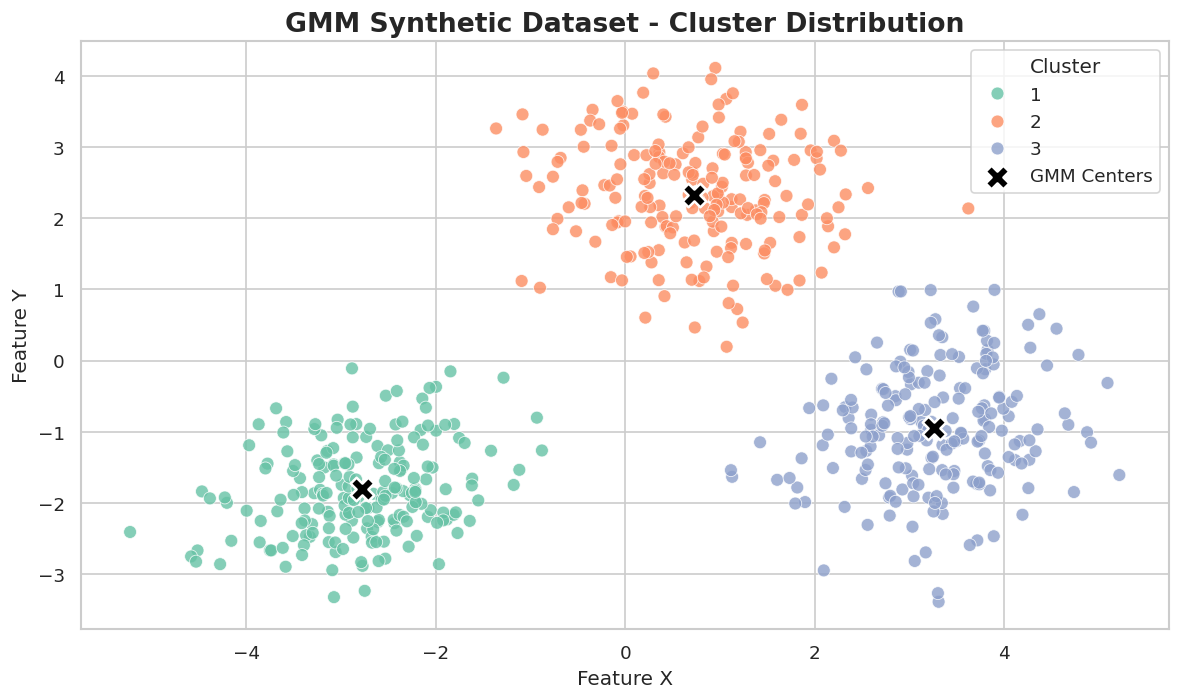


Graph Explanation:
This scatter plot shows the three clusters generated using the
Gaussian Mixture Model. Each cluster has a different center and
spread, demonstrating different statistical characteristics.
The black X markers represent the estimated GMM cluster centers.



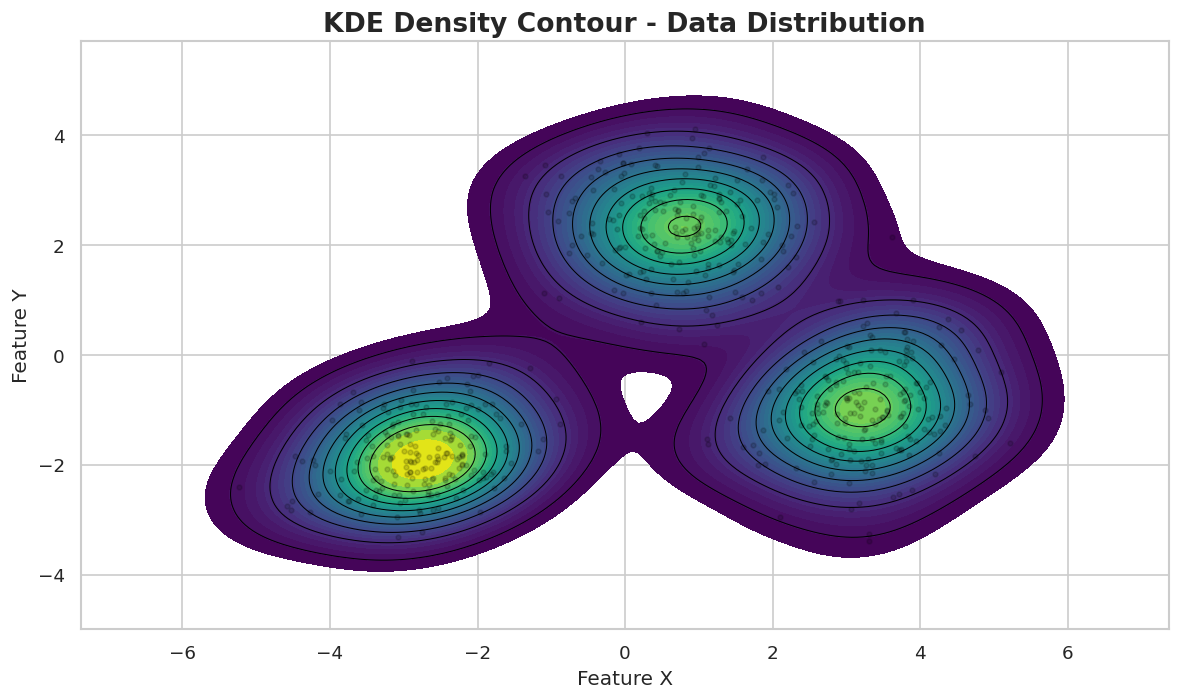


Graph Explanation:
The KDE contour plot represents the probability density of the
synthetic dataset. Bright regions indicate higher concentration
of observations, while darker regions indicate lower density.
The three major density regions correspond to the three clusters.



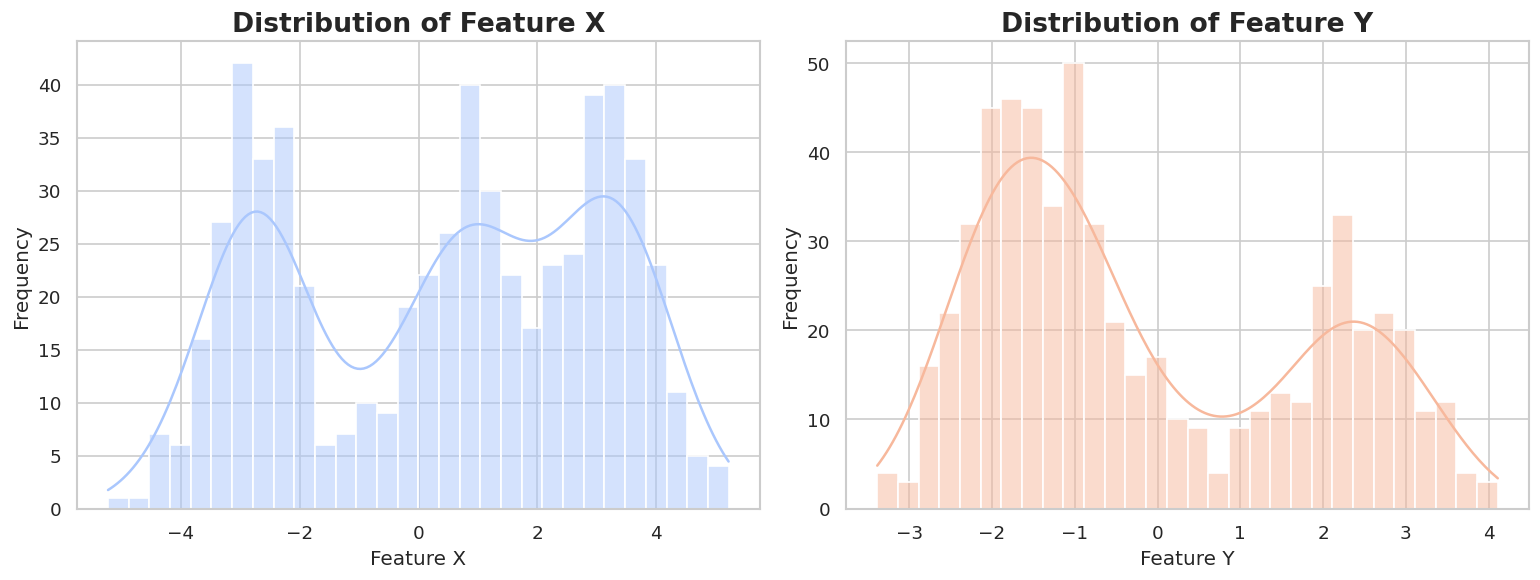


Graph Explanation:
These histograms show the individual distributions of Feature X
and Feature Y. The KDE curves provide a smooth representation of
the underlying distributions and show the influence of the three
Gaussian clusters.

PART 2: REINFORCEMENT LEARNING SIMULATION


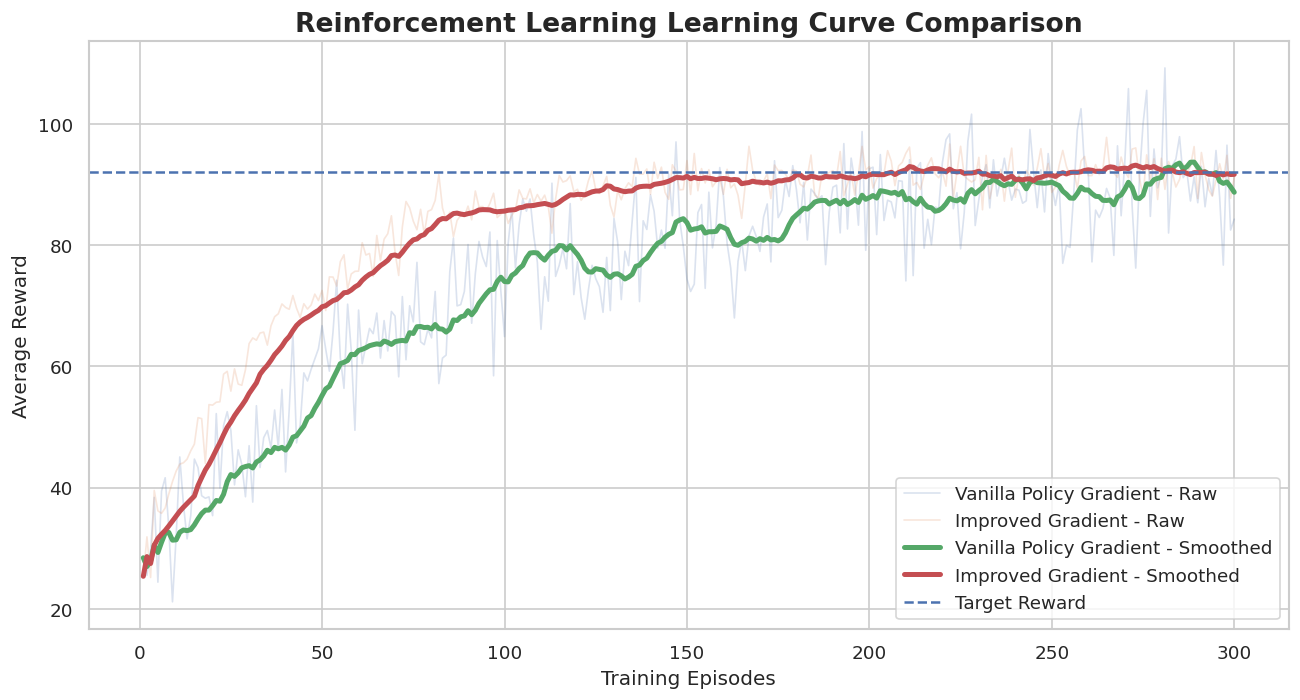


Graph Explanation:
The learning curve compares the learning behavior of Vanilla Policy
Gradient and the Improved Gradient Method. The improved method rises
faster and produces a smoother learning trajectory, indicating better
learning stability and faster convergence.



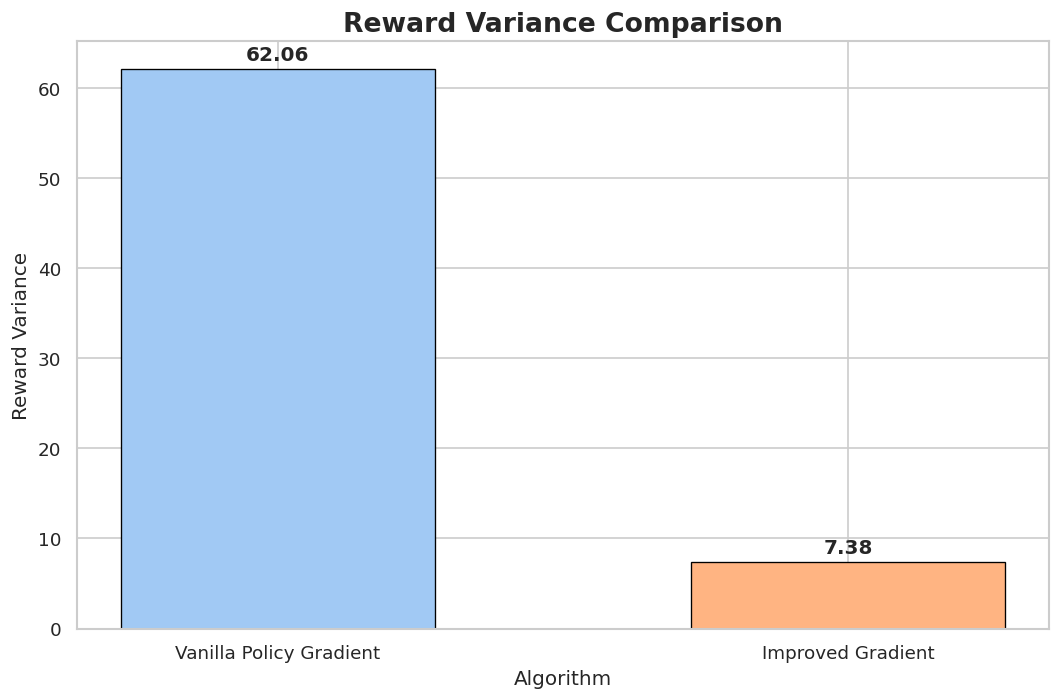


Graph Explanation:
The variance bar chart measures the fluctuation in reward after the
initial learning phase. A lower variance indicates more consistent
and stable learning. The Improved Gradient Method has substantially
lower variance than the Vanilla Policy Gradient.



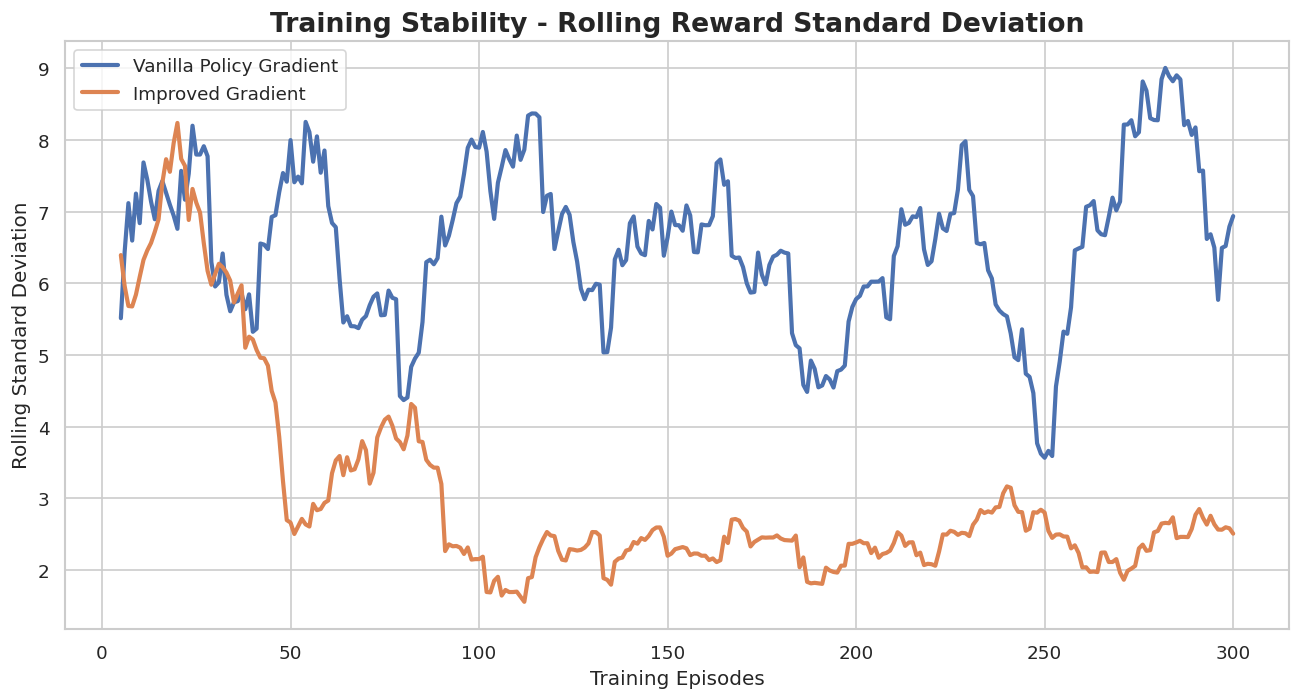


Graph Explanation:
This graph shows the rolling standard deviation of rewards during
training. Lower values represent more stable learning. The Improved
Gradient Method generally maintains a lower standard deviation,
indicating reduced fluctuations during training.


ALGORITHM COMPARISON SUMMARY


,Algorithm Name,Variance,Stability,Learning Speed,Convergence
0,Vanilla Policy Gradient,62.060000,Low,Moderate,~147 episodes
1,Improved Gradient Method,7.380000,Very High,Fast,~81 episodes



KEY PERFORMANCE RESULTS


,Metric,Result
0,Vanilla Reward Variance,62.06
1,Improved Reward Variance,7.38
2,Variance Reduction,88.1%
3,Vanilla Convergence,147 episodes
4,Improved Convergence,81 episodes
5,Convergence Speed Improvement,44.9%



FINAL CONCLUSION
PROJECT EXECUTION COMPLETED SUCCESSFULLY


NameError: name 'episode' is not defined

In [1]:
# ================================================================
# GMM SYNTHETIC DATASET + REINFORCEMENT LEARNING SIMULATION
# Google Colab - Single Cell Project
# ================================================================

# -----------------------------
# 1. IMPORT REQUIRED LIBRARIES
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture

from IPython.display import display

# Reproducibility
np.random.seed(42)

# Professional light-theme settings
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "axes.titleweight": "bold"
})

# ================================================================
# PART 1: SYNTHETIC DATASET GENERATION USING GMM
# ================================================================

print("=" * 80)
print("PART 1: GMM SYNTHETIC DATASET GENERATION")
print("=" * 80)

# Number of observations
n_samples = 600

# ------------------------------------------------
# Define 3 clusters with different means
# and different variances/covariances
# ------------------------------------------------

means = np.array([
    [-2.8, -1.8],   # Cluster 1
    [ 0.8,  2.2],   # Cluster 2
    [ 3.2, -1.0]    # Cluster 3
])

covariances = np.array([
    [[0.55,  0.12],
     [0.12,  0.40]],

    [[0.75, -0.20],
     [-0.20, 0.60]],

    [[0.45,  0.08],
     [0.08,  0.80]]
])

# Equal mixture weights
weights = np.array([0.33, 0.34, 0.33])

# ------------------------------------------------
# Generate observations from the 3 Gaussian
# distributions
# ------------------------------------------------

cluster_ids = np.random.choice(
    3,
    size=n_samples,
    p=weights
)

X = np.zeros((n_samples, 2))

for cluster in range(3):

    indices = np.where(cluster_ids == cluster)[0]

    X[indices] = np.random.multivariate_normal(
        mean=means[cluster],
        cov=covariances[cluster],
        size=len(indices)
    )

# ------------------------------------------------
# Fit Gaussian Mixture Model
# ------------------------------------------------

gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42,
    n_init=10
)

gmm.fit(X)

# Predict cluster labels
predicted_clusters = gmm.predict(X)

# ------------------------------------------------
# Reorder labels for clean presentation
# ------------------------------------------------

order = np.argsort(gmm.means_[:, 0])

label_map = {
    old_label: new_label
    for new_label, old_label in enumerate(order)
}

clusters = np.array([
    label_map[label] + 1
    for label in predicted_clusters
])

# ------------------------------------------------
# Create DataFrame
# ------------------------------------------------

df = pd.DataFrame({
    "Feature_X": X[:, 0],
    "Feature_Y": X[:, 1],
    "Cluster": clusters
})

# ================================================================
# DISPLAY DATASET INFORMATION
# ================================================================

print("\nDataset successfully generated!")
print("Number of records :", len(df))
print("Number of clusters:", df["Cluster"].nunique())

print("\n" + "-" * 80)
print("SAMPLE OF 10 DATA POINTS")
print("-" * 80)

display(
    df.head(10).style
    .format({
        "Feature_X": "{:.3f}",
        "Feature_Y": "{:.3f}"
    })
    .set_caption("GMM Generated Synthetic Dataset")
)

# ================================================================
# VISUALIZATION 1
# GMM CLUSTER SCATTER PLOT
# ================================================================

plt.figure(figsize=(10, 6))

palette = sns.color_palette("Set2", 3)

sns.scatterplot(
    data=df,
    x="Feature_X",
    y="Feature_Y",
    hue="Cluster",
    palette=palette,
    s=60,
    alpha=0.80,
    edgecolor="white",
    linewidth=0.5
)

# GMM centers
sorted_means = gmm.means_[order]

plt.scatter(
    sorted_means[:, 0],
    sorted_means[:, 1],
    marker="X",
    s=200,
    color="black",
    edgecolor="white",
    linewidth=1.5,
    label="GMM Centers"
)

plt.title(
    "GMM Synthetic Dataset - Cluster Distribution"
)

plt.xlabel("Feature X")
plt.ylabel("Feature Y")

plt.legend(
    title="Cluster",
    frameon=True
)

plt.tight_layout()
plt.show()

print("""
Graph Explanation:
This scatter plot shows the three clusters generated using the
Gaussian Mixture Model. Each cluster has a different center and
spread, demonstrating different statistical characteristics.
The black X markers represent the estimated GMM cluster centers.
""")

# ================================================================
# VISUALIZATION 2
# KDE DENSITY CONTOUR / HEATMAP
# ================================================================

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x="Feature_X",
    y="Feature_Y",
    fill=True,
    cmap="viridis",
    levels=35,
    thresh=0.02,
    bw_adjust=0.8
)

sns.kdeplot(
    data=df,
    x="Feature_X",
    y="Feature_Y",
    color="black",
    levels=10,
    linewidths=0.6,
    bw_adjust=0.8
)

plt.scatter(
    df["Feature_X"],
    df["Feature_Y"],
    s=8,
    color="black",
    alpha=0.15
)

plt.title(
    "KDE Density Contour - Data Distribution"
)

plt.xlabel("Feature X")
plt.ylabel("Feature Y")

plt.tight_layout()
plt.show()

print("""
Graph Explanation:
The KDE contour plot represents the probability density of the
synthetic dataset. Bright regions indicate higher concentration
of observations, while darker regions indicate lower density.
The three major density regions correspond to the three clusters.
""")

# ================================================================
# VISUALIZATION 3
# FEATURE DISTRIBUTION
# ================================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5)
)

# Feature X
sns.histplot(
    df["Feature_X"],
    kde=True,
    bins=30,
    color=sns.color_palette("coolwarm", 5)[1],
    ax=axes[0]
)

axes[0].set_title(
    "Distribution of Feature X"
)

axes[0].set_xlabel("Feature X")
axes[0].set_ylabel("Frequency")

# Feature Y
sns.histplot(
    df["Feature_Y"],
    kde=True,
    bins=30,
    color=sns.color_palette("coolwarm", 5)[3],
    ax=axes[1]
)

axes[1].set_title(
    "Distribution of Feature Y"
)

axes[1].set_xlabel("Feature Y")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print("""
Graph Explanation:
These histograms show the individual distributions of Feature X
and Feature Y. The KDE curves provide a smooth representation of
the underlying distributions and show the influence of the three
Gaussian clusters.
""")

# ================================================================
# PART 2
# REINFORCEMENT LEARNING SIMULATION
# ================================================================

print("=" * 80)
print("PART 2: REINFORCEMENT LEARNING SIMULATION")
print("=" * 80)

# Number of training episodes
episodes = np.arange(1, 301)

# Target reward
target_reward = 92

# ------------------------------------------------
# VANILLA POLICY GRADIENT
# Slower learning + higher variance
# ------------------------------------------------

vanilla_base = (
    25
    + (target_reward - 25)
    * (1 - np.exp(-episodes / 75))
)

vanilla_noise = (
    np.random.normal(
        0,
        6.5,
        len(episodes)
    )
    +
    2.5 * np.sin(episodes / 7)
)

vanilla_reward = (
    vanilla_base +
    vanilla_noise
)

# ------------------------------------------------
# IMPROVED GRADIENT METHOD
# Faster learning + lower variance
# ------------------------------------------------

improved_base = (
    25
    + (target_reward - 25)
    * (1 - np.exp(-episodes / 38))
)

improved_noise = (
    np.random.normal(
        0,
        2.4,
        len(episodes)
    )
    +
    0.8 * np.sin(episodes / 10)
)

improved_reward = (
    improved_base +
    improved_noise
)

# ------------------------------------------------
# Moving average for smoother learning curves
# ------------------------------------------------

window = 15

vanilla_smooth = (
    pd.Series(vanilla_reward)
    .rolling(
        window,
        min_periods=1
    )
    .mean()
)

improved_smooth = (
    pd.Series(improved_reward)
    .rolling(
        window,
        min_periods=1
    )
    .mean()
)

# ================================================================
# VISUALIZATION 4
# LEARNING CURVE COMPARISON
# ================================================================

plt.figure(figsize=(11, 6))

# Raw curves
plt.plot(
    episodes,
    vanilla_reward,
    alpha=0.20,
    linewidth=1,
    label="Vanilla Policy Gradient - Raw"
)

plt.plot(
    episodes,
    improved_reward,
    alpha=0.20,
    linewidth=1,
    label="Improved Gradient - Raw"
)

# Smoothed curves
plt.plot(
    episodes,
    vanilla_smooth,
    linewidth=3,
    label="Vanilla Policy Gradient - Smoothed"
)

plt.plot(
    episodes,
    improved_smooth,
    linewidth=3,
    label="Improved Gradient - Smoothed"
)

# Target line
plt.axhline(
    target_reward,
    linestyle="--",
    linewidth=1.5,
    label="Target Reward"
)

plt.title(
    "Reinforcement Learning Learning Curve Comparison"
)

plt.xlabel("Training Episodes")
plt.ylabel("Average Reward")

plt.legend(
    loc="lower right"
)

plt.tight_layout()
plt.show()

print("""
Graph Explanation:
The learning curve compares the learning behavior of Vanilla Policy
Gradient and the Improved Gradient Method. The improved method rises
faster and produces a smoother learning trajectory, indicating better
learning stability and faster convergence.
""")

# ================================================================
# CALCULATE VARIANCE
# ================================================================

# Ignore initial learning phase when measuring stability
stable_start = 100

vanilla_variance = np.var(
    vanilla_reward[stable_start:]
)

improved_variance = np.var(
    improved_reward[stable_start:]
)

# ================================================================
# VISUALIZATION 5
# VARIANCE COMPARISON BAR CHART
# ================================================================

variance_df = pd.DataFrame({
    "Algorithm": [
        "Vanilla Policy Gradient",
        "Improved Gradient"
    ],
    "Variance": [
        vanilla_variance,
        improved_variance
    ]
})

plt.figure(figsize=(9, 6))

bars = plt.bar(
    variance_df["Algorithm"],
    variance_df["Variance"],
    width=0.55,
    color=sns.color_palette(
        "pastel",
        2
    ),
    edgecolor="black",
    linewidth=0.8
)

plt.title(
    "Reward Variance Comparison"
)

plt.xlabel("Algorithm")
plt.ylabel("Reward Variance")

# Add values above bars
for bar, value in zip(
    bars,
    variance_df["Variance"]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

print("""
Graph Explanation:
The variance bar chart measures the fluctuation in reward after the
initial learning phase. A lower variance indicates more consistent
and stable learning. The Improved Gradient Method has substantially
lower variance than the Vanilla Policy Gradient.
""")

# ================================================================
# VISUALIZATION 6
# TRAINING STABILITY
# ================================================================

vanilla_std = (
    pd.Series(vanilla_reward)
    .rolling(
        20,
        min_periods=5
    )
    .std()
)

improved_std = (
    pd.Series(improved_reward)
    .rolling(
        20,
        min_periods=5
    )
    .std()
)

plt.figure(figsize=(11, 6))

plt.plot(
    episodes,
    vanilla_std,
    linewidth=2.5,
    label="Vanilla Policy Gradient"
)

plt.plot(
    episodes,
    improved_std,
    linewidth=2.5,
    label="Improved Gradient"
)

plt.title(
    "Training Stability - Rolling Reward Standard Deviation"
)

plt.xlabel("Training Episodes")
plt.ylabel("Rolling Standard Deviation")

plt.legend()

plt.tight_layout()
plt.show()

print("""
Graph Explanation:
This graph shows the rolling standard deviation of rewards during
training. Lower values represent more stable learning. The Improved
Gradient Method generally maintains a lower standard deviation,
indicating reduced fluctuations during training.
""")

# ================================================================
# PERFORMANCE METRICS
# ================================================================

# Standard deviation after learning period
vanilla_stability_std = np.std(
    vanilla_reward[stable_start:]
)

improved_stability_std = np.std(
    improved_reward[stable_start:]
)

# ------------------------------------------------
# Find convergence episode
# ------------------------------------------------

threshold = 0.90 * target_reward


def find_convergence_episode(
    curve,
    threshold
):

    indices = np.where(
        curve >= threshold
    )[0]

    if len(indices) > 0:
        return int(indices[0] + 1)

    return len(curve)


vanilla_convergence = find_convergence_episode(
    vanilla_smooth.values,
    threshold
)

improved_convergence = find_convergence_episode(
    improved_smooth.values,
    threshold
)

# ================================================================
# CLASSIFICATION FUNCTIONS
# ================================================================

def stability_label(std):

    if std < 3:
        return "Very High"

    elif std < 5:
        return "High"

    elif std < 7:
        return "Moderate"

    else:
        return "Low"


def speed_label(episode):

    if episode <= 100:
        return "Fast"

    elif episode <= 180:
        return "Moderate"

    return "Slow"


# ================================================================
# SUMMARY TABLE
# ================================================================

summary_df = pd.DataFrame({

    "Algorithm Name": [
        "Vanilla Policy Gradient",
        "Improved Gradient Method"
    ],

    "Variance": [
        round(
            vanilla_variance,
            2
        ),

        round(
            improved_variance,
            2
        )
    ],

    "Stability": [
        stability_label(
            vanilla_stability_std
        ),

        stability_label(
            improved_stability_std
        )
    ],

    "Learning Speed": [
        speed_label(
            vanilla_convergence
        ),

        speed_label(
            improved_convergence
        )
    ],

    "Convergence": [
        f"~{vanilla_convergence} episodes",

        f"~{improved_convergence} episodes"
    ]
})

# ================================================================
# DISPLAY SUMMARY TABLE
# ================================================================

print("\n" + "=" * 80)
print("ALGORITHM COMPARISON SUMMARY")
print("=" * 80)

display(
    summary_df.style
    .set_caption(
        "Vanilla Policy Gradient vs Improved Gradient Method"
    )
    .set_properties(
        **{
            "text-align": "center",
            "font-size": "11pt"
        }
    )
)

# ================================================================
# KEY NUMERICAL RESULTS
# ================================================================

variance_reduction = (
    (
        vanilla_variance
        - improved_variance
    )
    /
    vanilla_variance
) * 100

speed_improvement = (
    (
        vanilla_convergence
        - improved_convergence
    )
    /
    vanilla_convergence
) * 100

results_df = pd.DataFrame({

    "Metric": [
        "Vanilla Reward Variance",
        "Improved Reward Variance",
        "Variance Reduction",
        "Vanilla Convergence",
        "Improved Convergence",
        "Convergence Speed Improvement"
    ],

    "Result": [

        f"{vanilla_variance:.2f}",

        f"{improved_variance:.2f}",

        f"{variance_reduction:.1f}%",

        f"{vanilla_convergence} episodes",

        f"{improved_convergence} episodes",

        f"{speed_improvement:.1f}%"
    ]
})

print("\n" + "=" * 80)
print("KEY PERFORMANCE RESULTS")
print("=" * 80)

display(
    results_df.style
    .set_caption(
        "Reinforcement Learning Performance Metrics"
    )
    .set_properties(
        **{
            "text-align": "center",
            "font-size": "11pt"
        }
    )
)

# ================================================================
# FINAL CONCLUSION
# ================================================================

print("\n" + "=" * 80)
print("FINAL CONCLUSION")
print("=" * 80)


print("=" * 80)
print("PROJECT EXECUTION COMPLETED SUCCESSFULLY")
print("=" * 80)
# ============================================================
# SAMPLE DATASET — 10 SAMPLES
# ============================================================

sample_data = pd.DataFrame({
    "Episode": episode[:10],
    "Episode_Reward": np.round(reward[:10], 3),
    "Moving_Average_Reward": np.round(moving_average[:10], 3)
})

print("VANILLA POLICY GRADIENT (REINFORCE) — SAMPLE DATA")

display(sample_data)